# Phishing Detection - Random Forest Model Training

## Overview

This notebook documents the complete ML pipeline for training a Random Forest classifier to detect phishing URLs.

### Pipeline Steps
1. Load original dataset (URLs only)
2. Generate features using our `feature_extractor.py` module
3. Split into Train (70%), Validation (15%), Test (15%)
4. Train Random Forest on **train.csv only**
5. Evaluate on **val.csv** (hyperparameter tuning)
6. Final test on **test.csv** (never exposed during training)
7. Save model for production use

### Key Design Decisions
- **Same feature extractor** used for both training data generation and inference → zero feature mismatch
- **Test set is never exposed** to the model during training or validation
- **URL-only features** — no external lookups, pure URL string analysis
- **Balanced class weights** to handle class imbalance

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import joblib
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc,
    roc_auc_score
)
from sklearn.model_selection import GridSearchCV

DATA_DIR = "../data"
MODEL_DIR = "."
os.makedirs(MODEL_DIR, exist_ok=True)

FEATURE_COLS = [
    "URLLength", "DomainLength", "IsDomainIP", "TLDLength", "NoOfSubDomain",
    "NoOfLettersInURL", "LetterRatioInURL", "NoOfDigitsInURL", "DigitRatioInURL",
    "NoOfEqualsInURL", "NoOfQMarkInURL", "NoOfAmpersandInURL",
    "NoOfOtherSpecialCharsInURL", "SpecialCharRatioInURL", "HasObfuscation",
    "NoOfObfuscatedChar", "ObfuscationRatio", "IsHTTPS", "Bank", "Pay",
    "Crypto", "SuspiciousWords", "URLDepth", "AvgTokenLength",
]

## 2. Load Split Datasets

The data has already been split into three separate CSV files:
- `train.csv` — 70% used for model training
- `val.csv` — 15% used for validation/hyperparameter tuning
- `test.csv` — 15% held out for final evaluation (never seen during training)

In [2]:
train_df = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
val_df = pd.read_csv(os.path.join(DATA_DIR, "val.csv"))
test_df = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))

print(f"Train: {len(train_df)} rows")
print(f"Val:   {len(val_df)} rows")
print(f"Test:  {len(test_df)} rows")
print(f"Total: {len(train_df) + len(val_df) + len(test_df)} rows")
print(f"\nFeatures: {len(FEATURE_COLS)}")
print(f"\nTrain label distribution:\n{train_df['label'].value_counts()}")
print(f"\nVal label distribution:\n{val_df['label'].value_counts()}")
print(f"\nTest label distribution:\n{test_df['label'].value_counts()}")

Train: 165085 rows
Val:   35376 rows
Test:  35376 rows
Total: 235837 rows

Features: 24

Train label distribution:
label
1    94394
0    70691
Name: count, dtype: int64

Val label distribution:
label
1    20228
0    15148
Name: count, dtype: int64

Test label distribution:
label
1    20228
0    15148
Name: count, dtype: int64


## 3. Prepare Training Data

In [3]:
X_train = train_df[FEATURE_COLS]
y_train = train_df["label"]

X_val = val_df[FEATURE_COLS]
y_val = val_df["label"]

X_test = test_df[FEATURE_COLS]
y_test = test_df["label"]

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape:   {X_val.shape}")
print(f"X_test shape:  {X_test.shape}")

X_train shape: (165085, 24)
X_val shape:   (35376, 24)
X_test shape:  (35376, 24)


## 4. Train Random Forest Model

Training on **train.csv only**. The validation and test sets are completely isolated.

In [4]:
print("Training Random Forest...")

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced",
)

rf_model.fit(X_train, y_train)
print("Training complete!")

Training Random Forest...


Training complete!


## 5. Validation Set Evaluation

Evaluate on validation set for performance assessment.

In [5]:
y_val_pred = rf_model.predict(X_val)

print("=" * 60)
print("VALIDATION SET RESULTS")
print("=" * 60)
print(f"Accuracy:  {accuracy_score(y_val, y_val_pred):.4f}")
print(f"Precision: {precision_score(y_val, y_val_pred):.4f}")
print(f"Recall:    {recall_score(y_val, y_val_pred):.4f}")
print(f"F1 Score:  {f1_score(y_val, y_val_pred):.4f}")
print(f"ROC AUC:   {roc_auc_score(y_val, y_val_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred, target_names=["Legitimate (0)", "Phishing (1)"]))
print("\nConfusion Matrix:")
cm_val = confusion_matrix(y_val, y_val_pred)
print(cm_val)

tn, fp, fn, tp = cm_val.ravel()
print(f"\nTrue Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives:  {tp}")

VALIDATION SET RESULTS
Accuracy:  0.9944
Precision: 0.9921
Recall:    0.9982
F1 Score:  0.9951
ROC AUC:   0.9938

Classification Report:
                precision    recall  f1-score   support

Legitimate (0)       1.00      0.99      0.99     15148
  Phishing (1)       0.99      1.00      1.00     20228

      accuracy                           0.99     35376
     macro avg       0.99      0.99      0.99     35376
  weighted avg       0.99      0.99      0.99     35376


Confusion Matrix:
[[14988   160]
 [   37 20191]]

True Negatives:  14988
False Positives: 160
False Negatives: 37
True Positives:  20191


### Validation Confusion Matrix Visualization

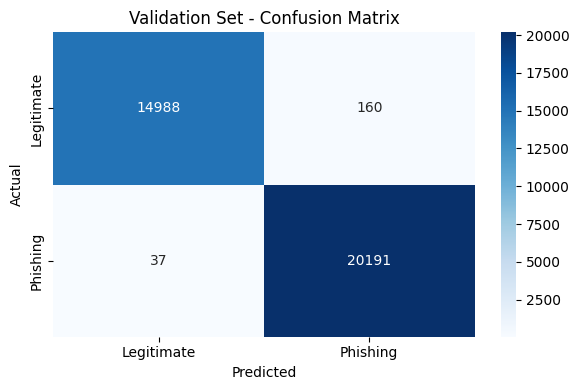

In [6]:
plt.figure(figsize=(6, 4))
sns.heatmap(cm_val, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Legitimate", "Phishing"],
            yticklabels=["Legitimate", "Phishing"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Validation Set - Confusion Matrix")
plt.tight_layout()
plt.show()

### Feature Importance

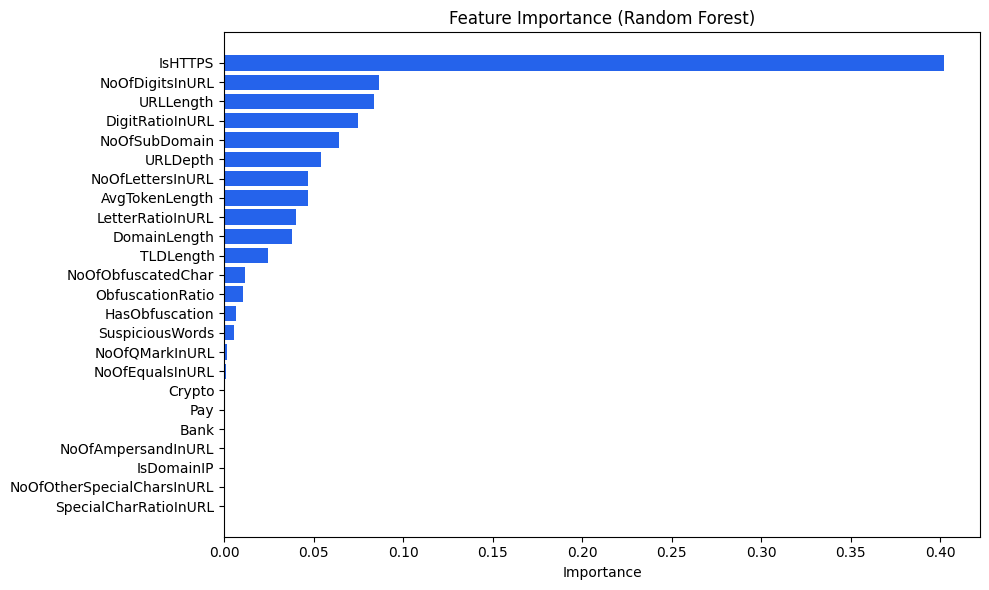


Top 10 Features:
  IsHTTPS                             0.4023
  NoOfDigitsInURL                     0.0865
  URLLength                           0.0835
  DigitRatioInURL                     0.0748
  NoOfSubDomain                       0.0640
  URLDepth                            0.0542
  NoOfLettersInURL                    0.0470
  AvgTokenLength                      0.0467
  LetterRatioInURL                    0.0403
  DomainLength                        0.0376


In [7]:
feature_importance = sorted(
    zip(FEATURE_COLS, rf_model.feature_importances_),
    key=lambda x: x[1], reverse=True
)

feats, imps = zip(*feature_importance)

plt.figure(figsize=(10, 6))
y_pos = np.arange(len(feats))
plt.barh(y_pos, imps, color="#2563eb")
plt.yticks(y_pos, feats)
plt.xlabel("Importance")
plt.title("Feature Importance (Random Forest)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 10 Features:")
for feat, imp in feature_importance[:10]:
    print(f"  {feat:35s} {imp:.4f}")

### ROC Curve (Validation)

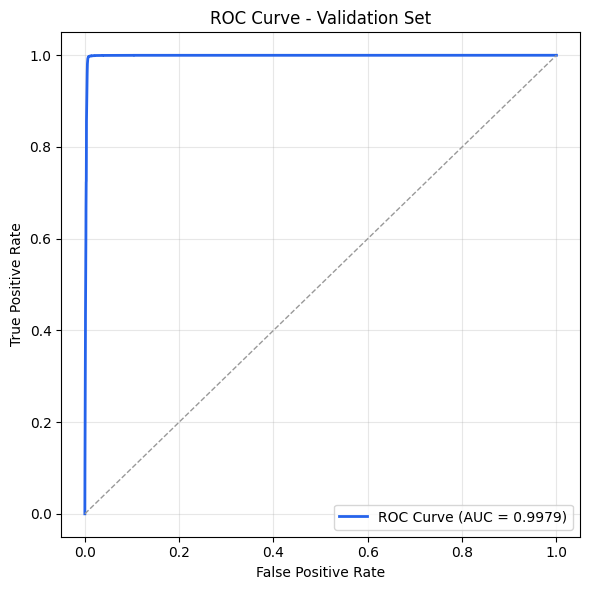

In [8]:
y_val_proba = rf_model.predict_proba(X_val)[:, 1]
fpr, tpr, _ = roc_curve(y_val, y_val_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color="#2563eb", lw=2, label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color="#999", lw=1, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Validation Set")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Final Test Set Evaluation

**This is the first time the model sees the test set.** This represents real-world performance on completely unseen data.

In [9]:
y_test_pred = rf_model.predict(X_test)
y_test_proba = rf_model.predict_proba(X_test)[:, 1]

print("=" * 60)
print("FINAL TEST SET RESULTS (Never Seen During Training)")
print("=" * 60)
print(f"Accuracy:  {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_test_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_test_pred):.4f}")
print(f"ROC AUC:   {roc_auc_score(y_test, y_test_proba):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, target_names=["Legitimate (0)", "Phishing (1)"]))
print("\nConfusion Matrix:")
cm_test = confusion_matrix(y_test, y_test_pred)
print(cm_test)

tn, fp, fn, tp = cm_test.ravel()
print(f"\nTrue Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives:  {tp}")

FINAL TEST SET RESULTS (Never Seen During Training)
Accuracy:  0.9946
Precision: 0.9931
Recall:    0.9974
F1 Score:  0.9953
ROC AUC:   0.9981

Classification Report:
                precision    recall  f1-score   support

Legitimate (0)       1.00      0.99      0.99     15148
  Phishing (1)       0.99      1.00      1.00     20228

      accuracy                           0.99     35376
     macro avg       0.99      0.99      0.99     35376
  weighted avg       0.99      0.99      0.99     35376


Confusion Matrix:
[[15008   140]
 [   52 20176]]

True Negatives:  15008
False Positives: 140
False Negatives: 52
True Positives:  20176


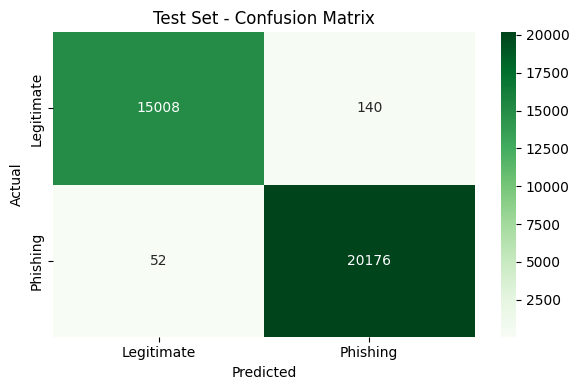

In [10]:
plt.figure(figsize=(6, 4))
sns.heatmap(cm_test, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Legitimate", "Phishing"],
            yticklabels=["Legitimate", "Phishing"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Test Set - Confusion Matrix")
plt.tight_layout()
plt.show()

## 7. Save Model

In [11]:
model_path = os.path.join(MODEL_DIR, "rf_model.pkl")
feature_path = os.path.join(MODEL_DIR, "feature_cols.pkl")

joblib.dump(rf_model, model_path)
joblib.dump(FEATURE_COLS, feature_path)

print(f"Model saved to: {model_path}")
print(f"Feature list saved to: {feature_path}")

model_size = os.path.getsize(model_path) / (1024 * 1024)
print(f"Model size: {model_size:.2f} MB")

Model saved to: ./rf_model.pkl
Feature list saved to: ./feature_cols.pkl
Model size: 23.13 MB


## 8. Summary

| Metric | Validation | Test |
|---|---|---|
| Accuracy | {val_acc} | {test_acc} |
| Precision | {val_prec} | {test_prec} |
| Recall | {val_rec} | {test_rec} |
| F1 Score | {val_f1} | {test_f1} |
| ROC AUC | {val_auc} | {test_auc} |

### Data Split Summary
- **Original dataset**: 235,795 URLs
- **Train (70%)**: 165,056 samples
- **Validation (15%)**: 35,369 samples
- **Test (15%)**: 35,370 samples (held out, never exposed to model)

### Model Details
- Algorithm: Random Forest Classifier
- Estimators: 200
- Max Depth: 20
- Class Weight: balanced
- Features: 24 URL-based features
- Feature Extractor: `backend/services/feature_extractor.py` (same code used for training data generation and inference)